In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import matplotlib.patches as patches

# Load gtf

In [2]:
%%time 
# === Load and filter GTF ===
gpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/RefGenome/refdata-gex-GRCh38-2024-A_genes.csv.gz"

gtf = pd.read_csv(gpath)

exons = gtf[gtf['Feature'] == 'exon']
print(f"{exons.shape=}")
exons.head()

exons.shape=(1586950, 27)
CPU times: user 10.4 s, sys: 1.6 s, total: 12 s
Wall time: 12.2 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
2,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NaN,NaN,1.0,ENSE00003753029,1.0,NaN,NaN,ENSP00000484918.1,NaN
10,GL000194.1,ENSEMBL,exon,114985,115018,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,1.0,ENSE00002299440,2.0,NaN,NaN,ENSP00000483280.1,NaN
11,GL000194.1,ENSEMBL,exon,112791,112850,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,2.0,ENSE00003739295,1.0,NaN,NaN,ENSP00000483280.1,NaN
12,GL000194.1,ENSEMBL,exon,53589,55676,.,-,.,ENSG00000277400,1,...,ENST00000613230,1.0,NaN,3.0,ENSE00003723764,1.0,NaN,NaN,ENSP00000483280.1,NaN
22,GL000194.1,ENSEMBL,exon,114985,115055,.,-,.,ENSG00000274847,1,...,MAFIP-201,1.0,NaN,1.0,ENSE00003736481,1.0,HGNC:31102,NaN,ENSP00000478910.1,NaN


In [3]:
gtf['Feature'].value_counts()

Feature
exon              1586950
CDS                876982
UTR                376798
transcript         226005
start_codon         97000
stop_codon          90690
gene                38606
Selenocysteine        130
Name: count, dtype: int64

In [4]:
# Genes of interest
query = [
    'TEAD1-203',
    'TEAD1-206',
    
    'CD63-201',
    'CD63-214',
    
    'ARHGAP29-201',
    'ARHGAP29-202',
    
    'FLNA-201',
    'FLNA-202',
    'FLNA-212',
    
    'RACK1-210',
    'RACK1-227',
    
    'JUND-201',
    'JUND-202',
]

tmp = gtf[gtf['transcript_name'].isin(query)].copy()
tmp = tmp[tmp['Feature'].isin(['transcript'])]
display(tmp)

,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
228743,chr1,HAVANA,transcript,94168904,94237584,.,-,.,ENSG00000137962,13,...,ARHGAP29-201,1.0,OTTHUMT00000029376.3,NaN,NaN,NaN,HGNC:30207,OTTHUMG00000010643.4,ENSP00000260526.6,CCDS748.1
228805,chr1,HAVANA,transcript,94201894,94237633,.,-,.,ENSG00000137962,13,...,ARHGAP29-202,1.0,OTTHUMT00000029381.1,NaN,NaN,NaN,HGNC:30207,OTTHUMG00000010643.4,ENSP00000359237.3,NaN
1058090,chr5,HAVANA,transcript,181236896,181243906,.,-,.,ENSG00000204628,12,...,RACK1-227,1.0,OTTHUMT00000372943.3,NaN,NaN,NaN,HGNC:4399,OTTHUMG00000163380.15,ENSP00000426909.1,CCDS34324.1
1058132,chr5,HAVANA,transcript,181236925,181243889,.,-,.,ENSG00000204628,12,...,RACK1-210,1.0,OTTHUMT00000373294.1,NaN,NaN,NaN,HGNC:4399,OTTHUMG00000163380.15,ENSP00000422198.1,NaN
1757562,chr11,HAVANA,transcript,12674420,12944737,.,+,.,ENSG00000187079,20,...,TEAD1-206,1.0,OTTHUMT00000386822.3,NaN,NaN,NaN,HGNC:11714,OTTHUMG00000165878.8,ENSP00000435233.2,CCDS7810.2
1757660,chr11,HAVANA,transcript,12879442,12944483,.,+,.,ENSG00000187079,20,...,TEAD1-203,1.0,OTTHUMT00000387220.1,NaN,NaN,NaN,HGNC:11714,OTTHUMG00000165878.8,ENSP00000435393.1,NaN
2073257,chr12,HAVANA,transcript,55725322,55729009,.,-,.,ENSG00000135404,12,...,CD63-201,1.0,OTTHUMT00000409235.1,NaN,NaN,NaN,HGNC:1692,OTTHUMG00000170454.5,ENSP00000257857.4,CCDS8890.1
2073354,chr12,HAVANA,transcript,55725469,55728482,.,-,.,ENSG00000135404,12,...,CD63-214,1.0,OTTHUMT00000409233.1,NaN,NaN,NaN,HGNC:1692,OTTHUMG00000170454.5,ENSP00000449337.1,CCDS8890.1
2939365,chr19,HAVANA,transcript,18279693,18281622,.,-,.,ENSG00000130522,6,...,JUND-201,NaN,OTTHUMT00000466318.3,NaN,NaN,NaN,HGNC:6206,OTTHUMG00000183355.6,ENSP00000252818.3,CCDS32959.1
2939372,chr19,HAVANA,transcript,18280018,18280929,.,-,.,ENSG00000130522,6,...,JUND-202,2.0,OTTHUMT00000466319.5,NaN,NaN,NaN,HGNC:6206,OTTHUMG00000183355.6,ENSP00000475153.2,NaN


## ARHGAP29

In [5]:
%%time

query = [
    'ARHGAP29-201',
    'ARHGAP29-202',
]

columns = [
    'transcript_name',
    'Chromosome',
    'Start', 
    'End',
    'Feature',
    'exon_id',
    'exon_version',
]

df = gtf[gtf['transcript_name'].isin(query)].copy()
df = df[df['Feature'].isin(['CDS', 'UTR'])]
df = df[columns]
print(f"{df.shape=}")

# Sort by transcript and exon number
df = df.sort_values(["transcript_name", "Start"])
print(df.head(10).to_string(index=False))

df.shape=(38, 7)
transcript_name Chromosome    Start      End Feature         exon_id  exon_version
   ARHGAP29-201       chr1 94168904 94173871     UTR ENSE00001180201           9.0
   ARHGAP29-201       chr1 94173871 94174749     CDS ENSE00001180201           9.0
   ARHGAP29-201       chr1 94177611 94177720     CDS ENSE00000932136           1.0
   ARHGAP29-201       chr1 94177851 94178167     CDS ENSE00003467206           1.0
   ARHGAP29-201       chr1 94179724 94179957     CDS ENSE00003595265           1.0
   ARHGAP29-201       chr1 94184150 94184288     CDS ENSE00003666360           1.0
   ARHGAP29-201       chr1 94184871 94185060     CDS ENSE00003681651           1.0
   ARHGAP29-201       chr1 94185341 94185481     CDS ENSE00003624020           1.0
   ARHGAP29-201       chr1 94186498 94186597     CDS ENSE00003564274           1.0
   ARHGAP29-201       chr1 94188836 94188941     CDS ENSE00003633414           1.0
CPU times: user 80.2 ms, sys: 0 ns, total: 80.2 ms
Wall time: 81.7 ms


In [6]:
### ARHGAP29-201 has very long 5' UTR whereas 202 does not
def truncate_utr_near_cds(df, transcript_name, keep_bp=1000, feature='UTR'):
    """Keep only the last `keep_bp` of a transcript's UTR nearest its CDS,
    dropping everything further away. Works regardless of strand, since it
    looks at which side of the CDS the UTR sits on in genomic coordinates."""
    tx_df = df[df['transcript_name'] == transcript_name]
    cds = tx_df[tx_df['Feature'] == 'CDS']
    if cds.empty:
        raise ValueError(f"No CDS found for {transcript_name}")
    cds_start, cds_end = cds['Start'].min(), cds['End'].max()

    new_rows = []
    for _, row in df.iterrows():
        if row['transcript_name'] != transcript_name or row['Feature'] != feature:
            new_rows.append(row)
            continue

        row = row.copy()
        if row['End'] <= cds_start:
            # UTR sits upstream of the CDS -> keep the end nearest the CDS
            row['Start'] = max(row['Start'], row['End'] - keep_bp)
        elif row['Start'] >= cds_end:
            # UTR sits downstream of the CDS -> keep the start nearest the CDS
            row['End'] = min(row['End'], row['Start'] + keep_bp)

        new_rows.append(row)
    return pd.DataFrame(new_rows)

df = truncate_utr_near_cds(df, 'ARHGAP29-201', keep_bp=1000)
df.head()

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version
228793,ARHGAP29-201,chr1,94172871,94173871,UTR,ENSE00001180201,9.0
228789,ARHGAP29-201,chr1,94173871,94174749,CDS,ENSE00001180201,9.0
228787,ARHGAP29-201,chr1,94177611,94177720,CDS,ENSE00000932136,1.0
228785,ARHGAP29-201,chr1,94177851,94178167,CDS,ENSE00003467206,1.0
228783,ARHGAP29-201,chr1,94179724,94179957,CDS,ENSE00003595265,1.0


In [7]:
gap = 20

intervals = df[['Chromosome','Start','End']].sort_values('Start').reset_index(drop=True)
merged_rows = []
current_start = None
current_end = None
chrom = None

for _, row in intervals.iterrows():
    if current_start is None:
        chrom = row['Chromosome']
        current_start = row['Start']
        current_end = row['End']
        continue

    if row['Start'] <= current_end:
        current_end = max(current_end, row['End'])
    else:
        merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
        current_start = row['Start']
        current_end = row['End']

merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
merged_df = pd.DataFrame(merged_rows)
merged_df = merged_df.sort_values('Start').reset_index(drop=True)
merged_df['Length'] = merged_df['End'] - merged_df['Start']
merged_df['collapsed_start'] = merged_df['Length'].shift(fill_value=0).cumsum() + gap * merged_df.index
merged_df['collapsed_end'] = merged_df['collapsed_start'] + merged_df['Length']

# Map exons to collapsed coordinates
def map_exon(row, merged_df):
    hit = merged_df[(merged_df['Start'] <= row['Start']) & (merged_df['End'] >= row['End'])]
    if hit.empty:
        raise ValueError(f"Exon not contained in any merged interval: {row}")
    hit = hit.iloc[0]
    offset = row['Start'] - hit['Start']
    return pd.Series({
        'collapsed_start': hit['collapsed_start'] + offset,
        'collapsed_end': hit['collapsed_start'] + offset + (row['End'] - row['Start'])
    })

df[['collapsed_start', 'collapsed_end']] = df.apply(map_exon, axis=1, merged_df=merged_df)

display(df)

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version,collapsed_start,collapsed_end
228793,ARHGAP29-201,chr1,94172871,94173871,UTR,ENSE00001180201,9.0,0,1000
228789,ARHGAP29-201,chr1,94173871,94174749,CDS,ENSE00001180201,9.0,1000,1878
228787,ARHGAP29-201,chr1,94177611,94177720,CDS,ENSE00000932136,1.0,1898,2007
228785,ARHGAP29-201,chr1,94177851,94178167,CDS,ENSE00003467206,1.0,2027,2343
228783,ARHGAP29-201,chr1,94179724,94179957,CDS,ENSE00003595265,1.0,2363,2596
228781,ARHGAP29-201,chr1,94184150,94184288,CDS,ENSE00003666360,1.0,2616,2754
228779,ARHGAP29-201,chr1,94184871,94185060,CDS,ENSE00003681651,1.0,2774,2963
228777,ARHGAP29-201,chr1,94185341,94185481,CDS,ENSE00003624020,1.0,2983,3123
228775,ARHGAP29-201,chr1,94186498,94186597,CDS,ENSE00003564274,1.0,3143,3242
228773,ARHGAP29-201,chr1,94188836,94188941,CDS,ENSE00003633414,1.0,3262,3367


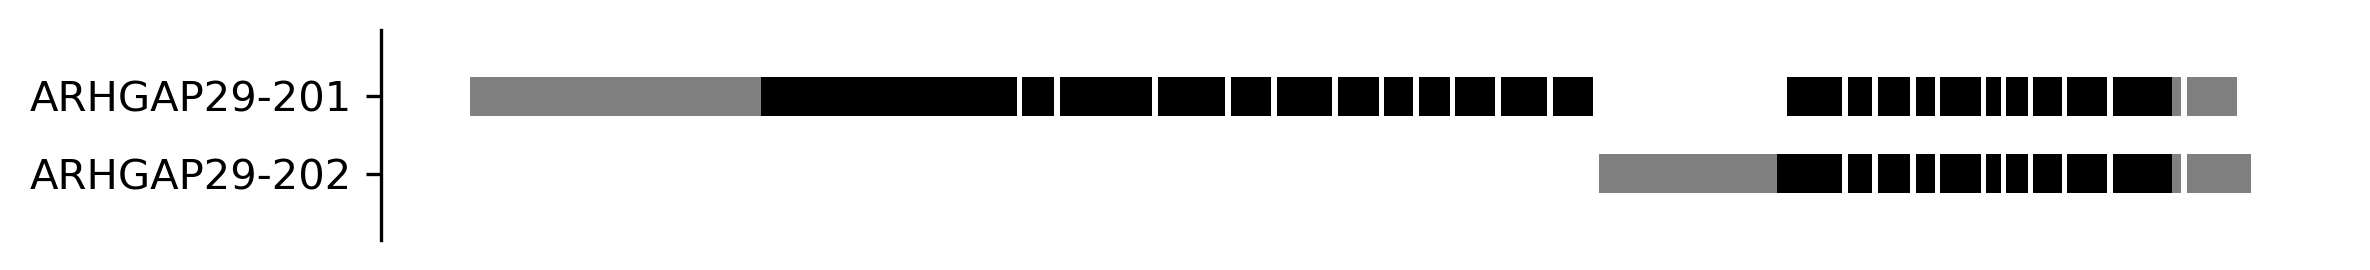

In [8]:
exon_height = 0.5

df['tx_num'] = df['transcript_name'].str.extract(r'-(\d+)$').astype(int)
df = df.sort_values('tx_num')
transcripts = df['transcript_name'].unique()

df = df.sort_values(['tx_num', 'Start'])

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 8, len(transcripts)*0.5

fig, ax = plt.subplots()


for i, transcript in enumerate(transcripts):
    tdf = df[df['transcript_name'] == transcript]
    y = i
    for _, row in tdf.iterrows():
        color = 'black' if row['Feature']=='CDS' else 'grey' if row['Feature']=='UTR' else 'white'
        # color = 'grey' if row['Feature'] == 'UTR' else 'black'
        rect = patches.Rectangle(
            (row['collapsed_start'], y - exon_height / 2),
            row['collapsed_end'] - row['collapsed_start'],
            exon_height,
            linewidth=0,
            facecolor=color,
            zorder=10,
        )
        ax.add_patch(rect)

# Format
ax.set_yticks(range(len(transcripts)))
ax.set_yticklabels(transcripts)
ax.invert_yaxis()

ax.set_xticks([])
ax.set_xlabel('')
ax.set_facecolor('none')

plt.margins(y=0.4, x=0.05)
sns.despine(bottom=True)
plt.tight_layout()
fig = plt.gcf()
fig.set_facecolor('none')
plt.show()

## CD63

In [9]:
%%time

query = [
    'CD63-201',
    'CD63-214',
]

columns = [
    'transcript_name',
    'Chromosome',
    'Start', 
    'End',
    'Feature',
    'exon_id',
    'exon_version',
]

df = gtf[gtf['transcript_name'].isin(query)].copy()
df = df[df['Feature'].isin(['CDS', 'UTR'])]
df = df[columns]
print(f"{df.shape=}")

# Sort by transcript and exon number
df = df.sort_values(["transcript_name", "Start"])
print(df.head(10).to_string(index=False))

df.shape=(19, 7)
transcript_name Chromosome    Start      End Feature         exon_id  exon_version
       CD63-201      chr12 55725322 55725563     UTR ENSE00002325261           1.0
       CD63-201      chr12 55725563 55725626     CDS ENSE00002325261           1.0
       CD63-201      chr12 55725812 55725896     CDS ENSE00003489755           1.0
       CD63-201      chr12 55726120 55726261     CDS ENSE00003477196           1.0
       CD63-201      chr12 55726699 55726795     CDS ENSE00003590609           1.0
       CD63-201      chr12 55726889 55726964     CDS ENSE00003691001           1.0
       CD63-201      chr12 55727150 55727339     CDS ENSE00003567727           1.0
       CD63-201      chr12 55728275 55728341     CDS ENSE00000920077           1.0
       CD63-201      chr12 55728341 55728352     UTR ENSE00000920077           1.0
       CD63-201      chr12 55728952 55729009     UTR ENSE00001517772           3.0
CPU times: user 81.8 ms, sys: 49 μs, total: 81.9 ms
Wall time: 83.5 ms

In [10]:
gap = 20

intervals = df[['Chromosome','Start','End']].sort_values('Start').reset_index(drop=True)
merged_rows = []
current_start = None
current_end = None
chrom = None

for _, row in intervals.iterrows():
    if current_start is None:
        chrom = row['Chromosome']
        current_start = row['Start']
        current_end = row['End']
        continue

    if row['Start'] <= current_end:
        current_end = max(current_end, row['End'])
    else:
        merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
        current_start = row['Start']
        current_end = row['End']

merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
merged_df = pd.DataFrame(merged_rows)
merged_df = merged_df.sort_values('Start').reset_index(drop=True)
merged_df['Length'] = merged_df['End'] - merged_df['Start']
merged_df['collapsed_start'] = merged_df['Length'].shift(fill_value=0).cumsum() + gap * merged_df.index
merged_df['collapsed_end'] = merged_df['collapsed_start'] + merged_df['Length']

# Map exons to collapsed coordinates
def map_exon(row, merged_df):
    hit = merged_df[(merged_df['Start'] <= row['Start']) & (merged_df['End'] >= row['End'])]
    if hit.empty:
        raise ValueError(f"Exon not contained in any merged interval: {row}")
    hit = hit.iloc[0]
    offset = row['Start'] - hit['Start']
    return pd.Series({
        'collapsed_start': hit['collapsed_start'] + offset,
        'collapsed_end': hit['collapsed_start'] + offset + (row['End'] - row['Start'])
    })

df[['collapsed_start', 'collapsed_end']] = df.apply(map_exon, axis=1, merged_df=merged_df)

display(df)

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version,collapsed_start,collapsed_end
2073277,CD63-201,chr12,55725322,55725563,UTR,ENSE00002325261,1.0,0,241
2073273,CD63-201,chr12,55725563,55725626,CDS,ENSE00002325261,1.0,241,304
2073271,CD63-201,chr12,55725812,55725896,CDS,ENSE00003489755,1.0,324,408
2073269,CD63-201,chr12,55726120,55726261,CDS,ENSE00003477196,1.0,428,569
2073267,CD63-201,chr12,55726699,55726795,CDS,ENSE00003590609,1.0,589,685
2073265,CD63-201,chr12,55726889,55726964,CDS,ENSE00003691001,1.0,705,780
2073263,CD63-201,chr12,55727150,55727339,CDS,ENSE00003567727,1.0,800,989
2073260,CD63-201,chr12,55728275,55728341,CDS,ENSE00000920077,1.0,1009,1075
2073276,CD63-201,chr12,55728341,55728352,UTR,ENSE00000920077,1.0,1075,1086
2073275,CD63-201,chr12,55728952,55729009,UTR,ENSE00001517772,3.0,1236,1293


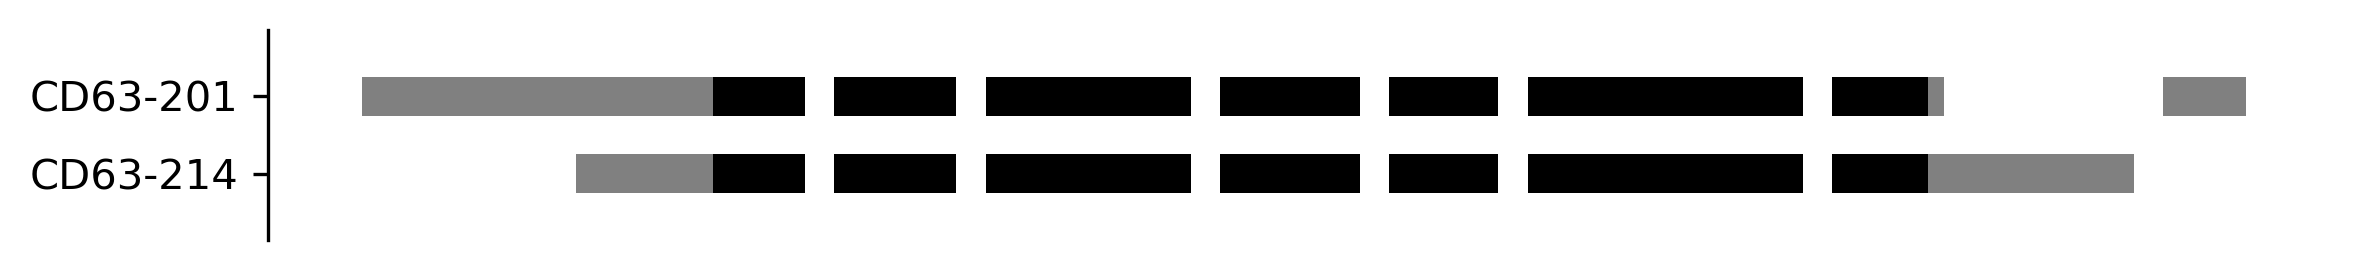

In [11]:
exon_height = 0.5

df['tx_num'] = df['transcript_name'].str.extract(r'-(\d+)$').astype(int)
df = df.sort_values('tx_num')
transcripts = df['transcript_name'].unique()

df = df.sort_values(['tx_num', 'Start'])

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 8, len(transcripts)*0.5

fig, ax = plt.subplots()


for i, transcript in enumerate(transcripts):
    tdf = df[df['transcript_name'] == transcript]
    y = i
    for _, row in tdf.iterrows():
        color = 'black' if row['Feature']=='CDS' else 'grey' if row['Feature']=='UTR' else 'white'
        # color = 'grey' if row['Feature'] == 'UTR' else 'black'
        rect = patches.Rectangle(
            (row['collapsed_start'], y - exon_height / 2),
            row['collapsed_end'] - row['collapsed_start'],
            exon_height,
            linewidth=0,
            facecolor=color,
            zorder=10,
        )
        ax.add_patch(rect)

# Format
ax.set_yticks(range(len(transcripts)))
ax.set_yticklabels(transcripts)
ax.invert_yaxis()

ax.set_xticks([])
ax.set_xlabel('')
ax.set_facecolor('none')

plt.margins(y=0.4, x=0.05)
sns.despine(bottom=True)
plt.tight_layout()
fig = plt.gcf()
fig.set_facecolor('none')
plt.show()

## FLNA

In [12]:
%%time

query = [
    'FLNA-201',
    'FLNA-202',
    'FLNA-212',
]

columns = [
    'transcript_name',
    'Chromosome',
    'Start', 
    'End',
    'Feature',
    'exon_id',
    'exon_version',
]

df = gtf[gtf['transcript_name'].isin(query)].copy()
df = df[df['Feature'].isin(['CDS', 'UTR'])]
df = df[columns]
print(f"{df.shape=}")

# Sort by transcript and exon number
df = df.sort_values(["transcript_name", "Start"])
print(df.head(10).to_string(index=False))

df.shape=(98, 7)
transcript_name Chromosome     Start       End Feature         exon_id  exon_version
       FLNA-201       chrX 154348528 154348851     UTR ENSE00002298822           2.0
       FLNA-201       chrX 154348851 154349036     CDS ENSE00002298822           2.0
       FLNA-201       chrX 154349361 154349565     CDS ENSE00003663935           1.0
       FLNA-201       chrX 154349648 154349867     CDS ENSE00003546981           1.0
       FLNA-201       chrX 154350030 154350207     CDS ENSE00003621135           1.0
       FLNA-201       chrX 154350908 154351041     CDS ENSE00003575553           1.0
       FLNA-201       chrX 154351580 154351696     CDS ENSE00003790175           1.0
       FLNA-201       chrX 154351883 154352021     CDS ENSE00003655364           1.0
       FLNA-201       chrX 154352180 154352447     CDS ENSE00003547693           1.0
       FLNA-201       chrX 154352552 154352675     CDS ENSE00003626883           1.0
CPU times: user 113 ms, sys: 0 ns, total: 113 ms

In [13]:
gap = 20

intervals = df[['Chromosome','Start','End']].sort_values('Start').reset_index(drop=True)
merged_rows = []
current_start = None
current_end = None
chrom = None

for _, row in intervals.iterrows():
    if current_start is None:
        chrom = row['Chromosome']
        current_start = row['Start']
        current_end = row['End']
        continue

    if row['Start'] <= current_end:
        current_end = max(current_end, row['End'])
    else:
        merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
        current_start = row['Start']
        current_end = row['End']

merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
merged_df = pd.DataFrame(merged_rows)
merged_df = merged_df.sort_values('Start').reset_index(drop=True)
merged_df['Length'] = merged_df['End'] - merged_df['Start']
merged_df['collapsed_start'] = merged_df['Length'].shift(fill_value=0).cumsum() + gap * merged_df.index
merged_df['collapsed_end'] = merged_df['collapsed_start'] + merged_df['Length']

# Map exons to collapsed coordinates
def map_exon(row, merged_df):
    hit = merged_df[(merged_df['Start'] <= row['Start']) & (merged_df['End'] >= row['End'])]
    if hit.empty:
        raise ValueError(f"Exon not contained in any merged interval: {row}")
    hit = hit.iloc[0]
    offset = row['Start'] - hit['Start']
    return pd.Series({
        'collapsed_start': hit['collapsed_start'] + offset,
        'collapsed_end': hit['collapsed_start'] + offset + (row['End'] - row['Start'])
    })

df[['collapsed_start', 'collapsed_end']] = df.apply(map_exon, axis=1, merged_df=merged_df)

display(df)

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version,collapsed_start,collapsed_end
3284897,FLNA-201,chrX,154348528,154348851,UTR,ENSE00002298822,2.0,0,323
3284894,FLNA-201,chrX,154348851,154349036,CDS,ENSE00002298822,2.0,323,508
3284892,FLNA-201,chrX,154349361,154349565,CDS,ENSE00003663935,1.0,528,732
3284890,FLNA-201,chrX,154349648,154349867,CDS,ENSE00003546981,1.0,752,971
3284888,FLNA-201,chrX,154350030,154350207,CDS,ENSE00003621135,1.0,991,1168
...,...,...,...,...,...,...,...,...,...
3285206,FLNA-202,chrX,154367640,154367738,CDS,ENSE00001600780,1.0,8424,8522
3285204,FLNA-202,chrX,154367841,154368090,CDS,ENSE00001761667,1.0,8542,8791
3285201,FLNA-202,chrX,154370872,154371245,CDS,ENSE00001451045,1.0,8811,9184
3285297,FLNA-202,chrX,154371245,154371361,UTR,ENSE00001451045,1.0,9184,9300


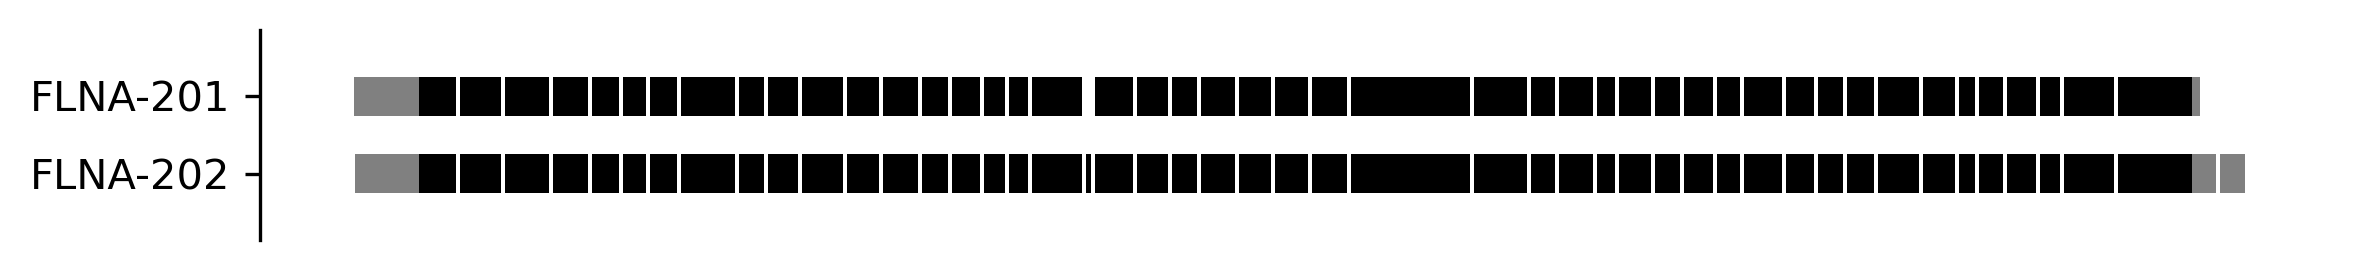

In [14]:
exon_height = 0.5

df['tx_num'] = df['transcript_name'].str.extract(r'-(\d+)$').astype(int)
df = df.sort_values('tx_num')
transcripts = df['transcript_name'].unique()

df = df.sort_values(['tx_num', 'Start'])

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 8, len(transcripts)*0.5

fig, ax = plt.subplots()

for i, transcript in enumerate(transcripts):
    tdf = df[df['transcript_name'] == transcript]
    y = i
    for _, row in tdf.iterrows():
        color = 'black' if row['Feature']=='CDS' else 'grey' if row['Feature']=='UTR' else 'white'
        # color = 'grey' if row['Feature'] == 'UTR' else 'black'
        rect = patches.Rectangle(
            (row['collapsed_start'], y - exon_height / 2),
            row['collapsed_end'] - row['collapsed_start'],
            exon_height,
            linewidth=0,
            facecolor=color,
            zorder=10,
        )
        ax.add_patch(rect)

# Format
ax.set_yticks(range(len(transcripts)))
ax.set_yticklabels(transcripts)
ax.invert_yaxis()

ax.set_xticks([])
ax.set_xlabel('')
ax.set_facecolor('none')

plt.margins(y=0.4, x=0.05)
sns.despine(bottom=True)
plt.tight_layout()
fig = plt.gcf()
fig.set_facecolor('none')
plt.show()

## RACK1

In [15]:
%%time

query = [
    'RACK1-210',
    'RACK1-227',
]

columns = [
    'transcript_name',
    'Chromosome',
    'Start', 
    'End',
    'Feature',
    'exon_id',
    'exon_version',
]

df = gtf[gtf['transcript_name'].isin(query)].copy()
df = df[df['Feature'].isin(['CDS', 'UTR'])]
df = df[columns]
print(f"{df.shape=}")

# Sort by transcript and exon number
df = df.sort_values(["transcript_name", "Start"])
print(df.head(10).to_string(index=False))

df.shape=(20, 7)
transcript_name Chromosome     Start       End Feature         exon_id  exon_version
      RACK1-210       chr5 181236925 181237042     UTR ENSE00002034638           1.0
      RACK1-210       chr5 181237608 181237719     UTR ENSE00003633005           1.0
      RACK1-210       chr5 181238098 181238239     UTR ENSE00003601546           1.0
      RACK1-210       chr5 181239066 181239177     UTR ENSE00003646006           1.0
      RACK1-210       chr5 181239486 181239582     UTR ENSE00003683879           1.0
      RACK1-210       chr5 181241491 181241576     UTR ENSE00003627526           1.0
      RACK1-210       chr5 181241576 181241639     CDS ENSE00003627526           1.0
      RACK1-210       chr5 181242169 181242345     CDS ENSE00003467948           1.0
      RACK1-210       chr5 181243691 181243800     CDS ENSE00002066089           1.0
      RACK1-210       chr5 181243800 181243889     UTR ENSE00002066089           1.0
CPU times: user 82.5 ms, sys: 0 ns, total: 82.5 

In [16]:
gap = 20

intervals = df[['Chromosome','Start','End']].sort_values('Start').reset_index(drop=True)
merged_rows = []
current_start = None
current_end = None
chrom = None

for _, row in intervals.iterrows():
    if current_start is None:
        chrom = row['Chromosome']
        current_start = row['Start']
        current_end = row['End']
        continue

    if row['Start'] <= current_end:
        current_end = max(current_end, row['End'])
    else:
        merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
        current_start = row['Start']
        current_end = row['End']

merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
merged_df = pd.DataFrame(merged_rows)
merged_df = merged_df.sort_values('Start').reset_index(drop=True)
merged_df['Length'] = merged_df['End'] - merged_df['Start']
merged_df['collapsed_start'] = merged_df['Length'].shift(fill_value=0).cumsum() + gap * merged_df.index
merged_df['collapsed_end'] = merged_df['collapsed_start'] + merged_df['Length']

# Map exons to collapsed coordinates
def map_exon(row, merged_df):
    hit = merged_df[(merged_df['Start'] <= row['Start']) & (merged_df['End'] >= row['End'])]
    if hit.empty:
        raise ValueError(f"Exon not contained in any merged interval: {row}")
    hit = hit.iloc[0]
    offset = row['Start'] - hit['Start']
    return pd.Series({
        'collapsed_start': hit['collapsed_start'] + offset,
        'collapsed_end': hit['collapsed_start'] + offset + (row['End'] - row['Start'])
    })

df[['collapsed_start', 'collapsed_end']] = df.apply(map_exon, axis=1, merged_df=merged_df)

display(df)

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version,collapsed_start,collapsed_end
1058152,RACK1-210,chr5,181236925,181237042,UTR,ENSE00002034638,1.0,29,146
1058151,RACK1-210,chr5,181237608,181237719,UTR,ENSE00003633005,1.0,166,277
1058150,RACK1-210,chr5,181238098,181238239,UTR,ENSE00003601546,1.0,297,438
1058149,RACK1-210,chr5,181239066,181239177,UTR,ENSE00003646006,1.0,458,569
1058148,RACK1-210,chr5,181239486,181239582,UTR,ENSE00003683879,1.0,589,685
1058147,RACK1-210,chr5,181241491,181241576,UTR,ENSE00003627526,1.0,705,790
1058139,RACK1-210,chr5,181241576,181241639,CDS,ENSE00003627526,1.0,790,853
1058137,RACK1-210,chr5,181242169,181242345,CDS,ENSE00003467948,1.0,873,1049
1058134,RACK1-210,chr5,181243691,181243800,CDS,ENSE00002066089,1.0,1069,1178
1058146,RACK1-210,chr5,181243800,181243889,UTR,ENSE00002066089,1.0,1178,1267


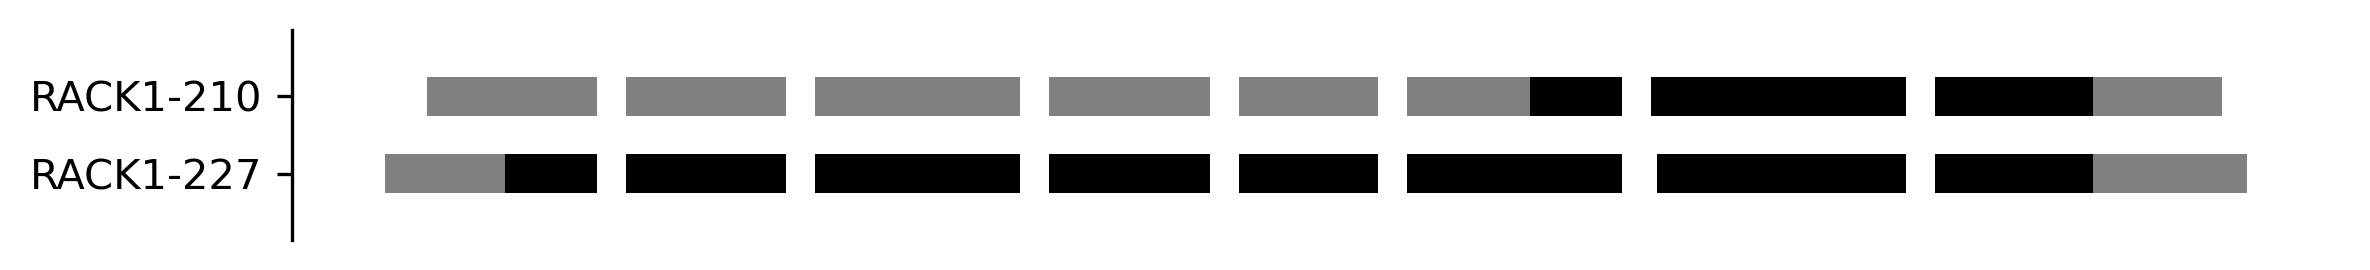

In [17]:
exon_height = 0.5

df['tx_num'] = df['transcript_name'].str.extract(r'-(\d+)$').astype(int)
df = df.sort_values('tx_num')
transcripts = df['transcript_name'].unique()

df = df.sort_values(['tx_num', 'Start'])

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 8, len(transcripts)*0.5

fig, ax = plt.subplots()


for i, transcript in enumerate(transcripts):
    tdf = df[df['transcript_name'] == transcript]
    y = i
    for _, row in tdf.iterrows():
        color = 'black' if row['Feature']=='CDS' else 'grey' if row['Feature']=='UTR' else 'white'
        # color = 'grey' if row['Feature'] == 'UTR' else 'black'
        rect = patches.Rectangle(
            (row['collapsed_start'], y - exon_height / 2),
            row['collapsed_end'] - row['collapsed_start'],
            exon_height,
            linewidth=0,
            facecolor=color,
            zorder=10,
        )
        ax.add_patch(rect)

# Format
ax.set_yticks(range(len(transcripts)))
ax.set_yticklabels(transcripts)
ax.invert_yaxis()

ax.set_xticks([])
ax.set_xlabel('')
ax.set_facecolor('none')

plt.margins(y=0.4, x=0.05)
sns.despine(bottom=True)
plt.tight_layout()
fig = plt.gcf()
fig.set_facecolor('none')
plt.show()

## TEAD1

In [18]:
%%time

query = [
    'TEAD1-203',
    'TEAD1-206',
]

columns = [
    'transcript_name',
    'Chromosome',
    'Start', 
    'End',
    'Feature',
    'exon_id',
    'exon_version',
]

df = gtf[gtf['transcript_name'].isin(query)].copy()
df = df[df['Feature'].isin(['CDS', 'UTR'])]
df = df[columns]
print(f"{df.shape=}")

# Sort by transcript and exon number
df = df.sort_values(["transcript_name", "Start"])
print(df.head(10).to_string(index=False))

df.shape=(25, 7)
transcript_name Chromosome    Start      End Feature         exon_id  exon_version
      TEAD1-203      chr11 12879442 12879665     UTR ENSE00002144916           1.0
      TEAD1-203      chr11 12879665 12879842     CDS ENSE00002144916           1.0
      TEAD1-203      chr11 12881004 12881051     CDS ENSE00000890040           1.0
      TEAD1-203      chr11 12881895 12881957     CDS ENSE00000890041           1.0
      TEAD1-203      chr11 12883000 12883125     CDS ENSE00001260349           1.0
      TEAD1-203      chr11 12901939 12902113     CDS ENSE00001260398           1.0
      TEAD1-203      chr11 12924911 12925052     CDS ENSE00001101315           1.0
      TEAD1-203      chr11 12930173 12930326     CDS ENSE00001101300           1.0
      TEAD1-203      chr11 12937108 12937219     CDS ENSE00002175034           1.0
      TEAD1-203      chr11 12937219 12944483     UTR ENSE00002175034           1.0
CPU times: user 83.6 ms, sys: 0 ns, total: 83.6 ms
Wall time: 85.2 ms


In [19]:
display(df[df['Feature'] == 'UTR'])

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version
1757679,TEAD1-203,chr11,12879442,12879665,UTR,ENSE00002144916,1.0
1757680,TEAD1-203,chr11,12937219,12944483,UTR,ENSE00002175034,1.0
1757589,TEAD1-206,chr11,12674420,12674834,UTR,ENSE00002199209,2.0
1757590,TEAD1-206,chr11,12675408,12675561,UTR,ENSE00001564120,1.0
1757591,TEAD1-206,chr11,12764178,12764232,UTR,ENSE00001481782,1.0
1757592,TEAD1-206,chr11,12937219,12944737,UTR,ENSE00002193739,2.0


In [20]:
### Both transcripts have a long 3' UTR; Will truncate same region from each UTR for plotting
def excise_region(df, feature, excise_start, excise_end):
    """Delete a genomic window from any row of `feature` that overlaps it,
    splitting the row into a left remnant and/or right remnant."""
    new_rows = []
    for _, row in df.iterrows():
        if row['Feature'] != feature or row['End'] <= excise_start or row['Start'] >= excise_end:
            new_rows.append(row)
            continue
        if row['Start'] < excise_start:
            left = row.copy()
            left['End'] = excise_start
            new_rows.append(left)
        if row['End'] > excise_end:
            right = row.copy()
            right['Start'] = excise_end
            new_rows.append(right)
    return pd.DataFrame(new_rows)

excise_start = 12938219 # 1000 bp after start of 3' UTR
excise_end = 12943483 # 1000 bp before end of TEAD1-203 3' UTR

df = excise_region(df, feature='UTR', excise_start=excise_start, excise_end=excise_end)

In [21]:
gap = 20

intervals = df[['Chromosome','Start','End']].sort_values('Start').reset_index(drop=True)
merged_rows = []
current_start = None
current_end = None
chrom = None

for _, row in intervals.iterrows():
    if current_start is None:
        chrom = row['Chromosome']
        current_start = row['Start']
        current_end = row['End']
        continue

    if row['Start'] <= current_end:
        current_end = max(current_end, row['End'])
    else:
        merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
        current_start = row['Start']
        current_end = row['End']

merged_rows.append({'Chromosome': chrom, 'Start': current_start, 'End': current_end})
merged_df = pd.DataFrame(merged_rows)
merged_df = merged_df.sort_values('Start').reset_index(drop=True)
merged_df['Length'] = merged_df['End'] - merged_df['Start']
merged_df['collapsed_start'] = merged_df['Length'].shift(fill_value=0).cumsum() + gap * merged_df.index
merged_df['collapsed_end'] = merged_df['collapsed_start'] + merged_df['Length']

# Map exons to collapsed coordinates
def map_exon(row, merged_df):
    hit = merged_df[(merged_df['Start'] <= row['Start']) & (merged_df['End'] >= row['End'])]
    if hit.empty:
        raise ValueError(f"Exon not contained in any merged interval: {row}")
    hit = hit.iloc[0]
    offset = row['Start'] - hit['Start']
    return pd.Series({
        'collapsed_start': hit['collapsed_start'] + offset,
        'collapsed_end': hit['collapsed_start'] + offset + (row['End'] - row['Start'])
    })

df[['collapsed_start', 'collapsed_end']] = df.apply(map_exon, axis=1, merged_df=merged_df)

display(df)

,transcript_name,Chromosome,Start,End,Feature,exon_id,exon_version,collapsed_start,collapsed_end
1757679,TEAD1-203,chr11,12879442,12879665,UTR,ENSE00002144916,1.0,1051,1274
1757662,TEAD1-203,chr11,12879665,12879842,CDS,ENSE00002144916,1.0,1274,1451
1757665,TEAD1-203,chr11,12881004,12881051,CDS,ENSE00000890040,1.0,1471,1518
1757667,TEAD1-203,chr11,12881895,12881957,CDS,ENSE00000890041,1.0,1538,1600
1757669,TEAD1-203,chr11,12883000,12883125,CDS,ENSE00001260349,1.0,1620,1745
1757671,TEAD1-203,chr11,12901939,12902113,CDS,ENSE00001260398,1.0,1765,1939
1757673,TEAD1-203,chr11,12924911,12925052,CDS,ENSE00001101315,1.0,1959,2100
1757675,TEAD1-203,chr11,12930173,12930326,CDS,ENSE00001101300,1.0,2120,2273
1757677,TEAD1-203,chr11,12937108,12937219,CDS,ENSE00002175034,1.0,2293,2404
1757680,TEAD1-203,chr11,12937219,12938219,UTR,ENSE00002175034,1.0,2404,3404


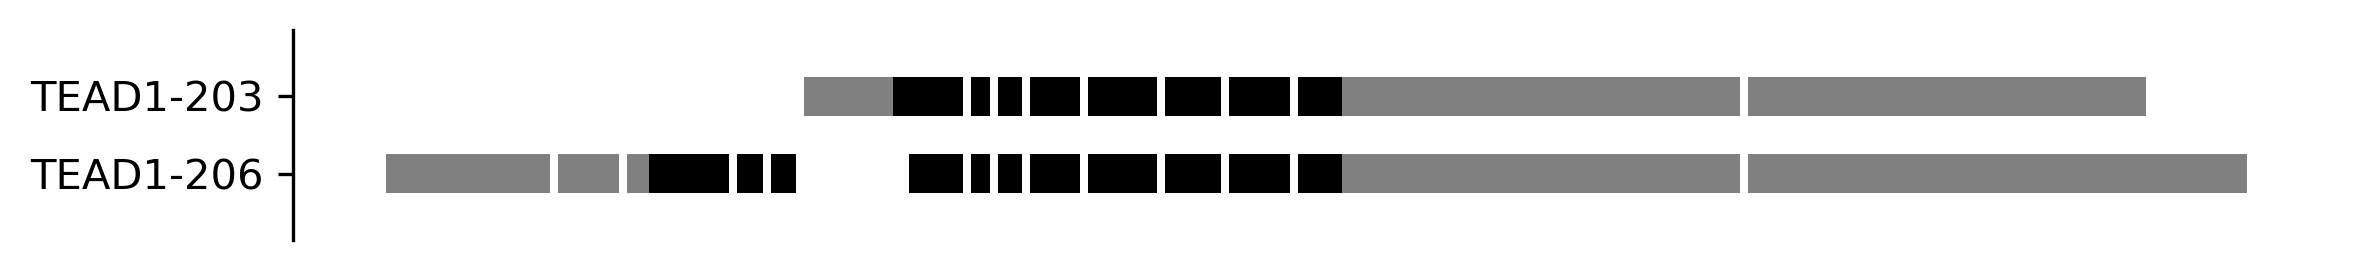

In [22]:
exon_height = 0.5

df['tx_num'] = df['transcript_name'].str.extract(r'-(\d+)$').astype(int)
df = df.sort_values('tx_num')
transcripts = df['transcript_name'].unique()

df = df.sort_values(['tx_num', 'Start'])

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 8, len(transcripts)*0.5

fig, ax = plt.subplots()


for i, transcript in enumerate(transcripts):
    tdf = df[df['transcript_name'] == transcript]
    y = i
    for _, row in tdf.iterrows():
        color = 'black' if row['Feature']=='CDS' else 'grey' if row['Feature']=='UTR' else 'white'
        # color = 'grey' if row['Feature'] == 'UTR' else 'black'
        rect = patches.Rectangle(
            (row['collapsed_start'], y - exon_height / 2),
            row['collapsed_end'] - row['collapsed_start'],
            exon_height,
            linewidth=0,
            facecolor=color,
            zorder=10,
        )
        ax.add_patch(rect)

# Format
ax.set_yticks(range(len(transcripts)))
ax.set_yticklabels(transcripts)
ax.invert_yaxis()

ax.set_xticks([])
ax.set_xlabel('')
ax.set_facecolor('none')

plt.margins(y=0.4, x=0.05)
sns.despine(bottom=True)
plt.tight_layout()
fig = plt.gcf()
fig.set_facecolor('none')
plt.show()